<a href="https://colab.research.google.com/github/ann849/nlp_project/blob/main/heartnlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('/content/heart_disease_uci.csv')

In [179]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [181]:
df.isna()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,False
916,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False
917,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
918,False,False,False,False,False,True,False,False,False,True,True,True,True,True,True,False


In [182]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [183]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


/tmp/ipykernel_9134/2962017728.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [184]:
cat_cols = ['fbs', 'restecg', 'exang']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

/tmp/ipykernel_9134/3045381192.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode().iloc[0])


In [152]:
df = df.drop(columns=['ca', 'thal', 'slope'])

In [153]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [154]:
df.duplicated().sum()

np.int64(0)

In [155]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    bool   
 8   restecg   920 non-null    object 
 9   thalch    920 non-null    float64
 10  exang     920 non-null    bool   
 11  oldpeak   920 non-null    float64
 12  num       920 non-null    int64  
dtypes: bool(2), float64(4), int64(3), object(4)
memory usage: 81.0+ KB


Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'num'],
      dtype='object')

In [156]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,num
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,460.500000,53.510870,131.995652,199.908696,137.692391,0.853261,0.995652
std,265.725422,9.424685,18.451300,109.040171,25.145235,1.058049,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,230.750000,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,1.000000
75%,690.250000,60.000000,140.000000,267.000000,156.000000,1.500000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


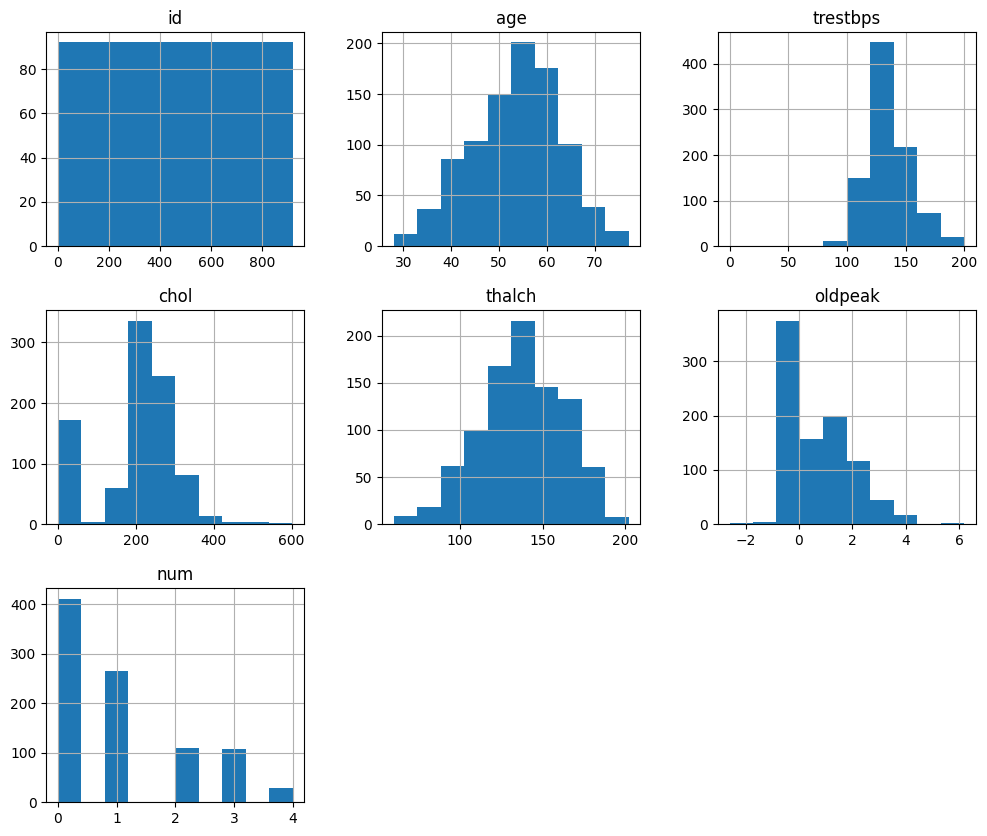

In [157]:
df.hist(figsize=(12,10))
plt.show()

In [158]:
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['num'])


/tmp/ipykernel_9134/2988178741.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#4CAF50', '#FF5252'])


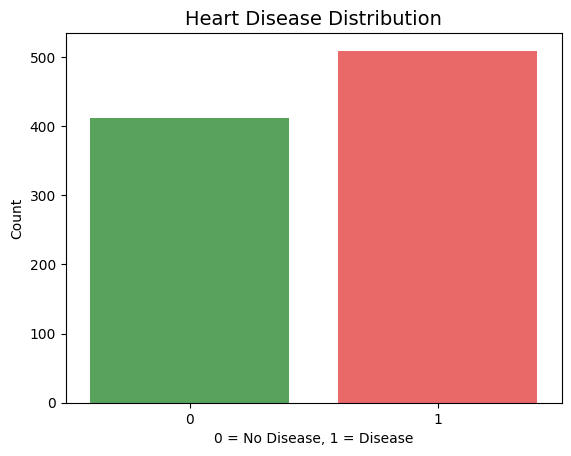

In [159]:
sns.countplot(x='target', data=df, palette=['#4CAF50', '#FF5252'])

plt.title("Heart Disease Distribution", fontsize=14)
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")

plt.show()

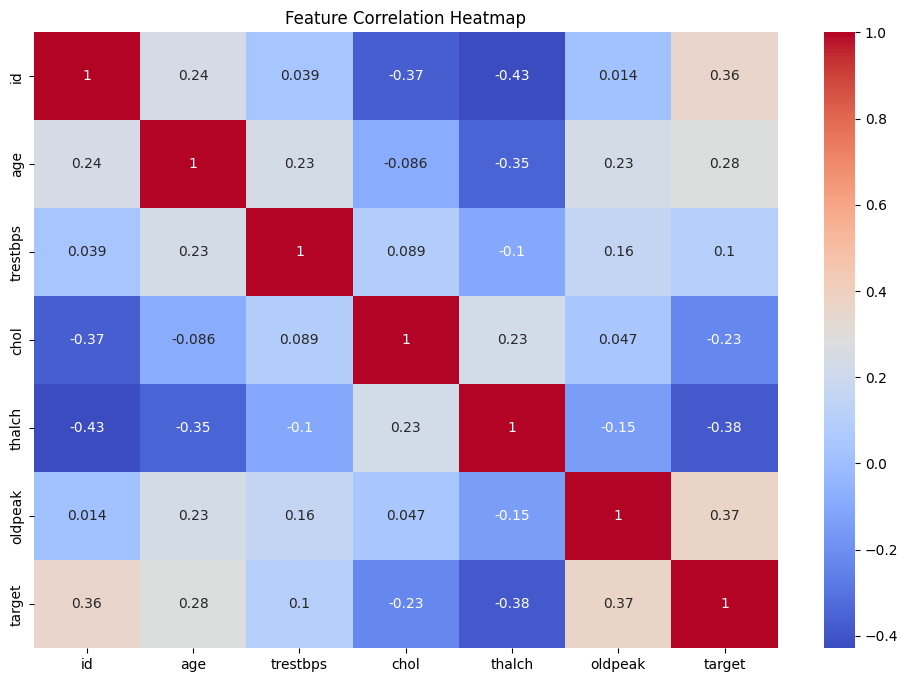

In [160]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

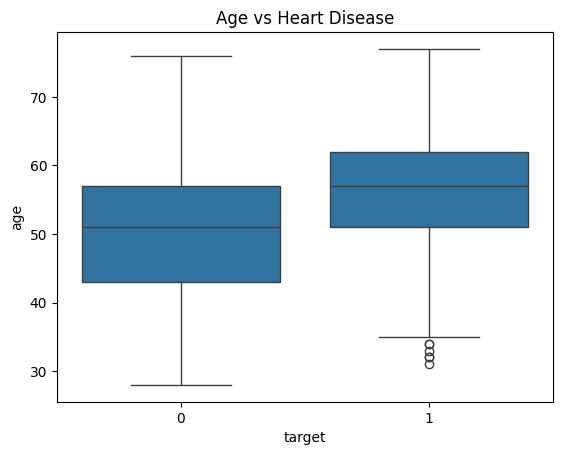

In [161]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

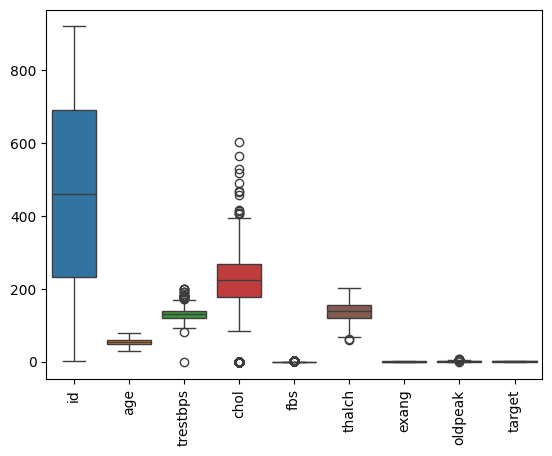

In [162]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [163]:
df = df.drop(columns=['id'])

In [164]:
df.select_dtypes(include=['object']).columns

Index(['sex', 'dataset', 'cp', 'restecg'], dtype='object')

In [165]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

In [166]:
df.dtypes

,0
age,int64
sex,int64
dataset,int64
cp,int64
trestbps,float64
chol,float64
fbs,bool
restecg,int64
thalch,float64
exang,bool


In [167]:
X = df.drop('target', axis=1)
y = df['target']

In [168]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [170]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=900)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=900)

In [171]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7989130434782609
              precision    recall  f1-score   support

           0       0.72      0.83      0.77        75
           1       0.87      0.78      0.82       109

    accuracy                           0.80       184
   macro avg       0.79      0.80      0.80       184
weighted avg       0.81      0.80      0.80       184



In [172]:
symptom_dict = {
    "chest pain": 3,
    "fatigue": 2,
    "shortness of breath": 3,
    "dizziness": 1,
    "nausea": 1
}

def extract_symptom_score(text):
    score = 0
    text = text.lower()

    matched = []

    for symptom, weight in symptom_dict.items():
        if symptom in text:
            score += weight
            matched.append(symptom)

    return score, matched

In [173]:
import numpy as np

def predict_risk(input_data, symptoms_text):

    symptom_score, matched = extract_symptom_score(symptoms_text)

    pred = model.predict([input_data])[0]

    # Risk logic
    if pred == 1 and symptom_score >= 3:
        risk = "HIGH RISK ⚠️"
    elif pred == 1:
        risk = "MEDIUM RISK"
    else:
        risk = "LOW RISK"

    # Explanation
    important_features = []
    for i, col in enumerate(X.columns):
        if input_data[i] > X[col].mean():
            important_features.append(col)

    return risk, matched, important_features

In [174]:
def what_if_analysis(base_input, new_chol):

    modified = base_input.copy()

    # assuming 'chol' index
    chol_index = list(X.columns).index('chol')
    modified[chol_index] = new_chol

    new_pred = model.predict([modified])[0]

    return new_pred

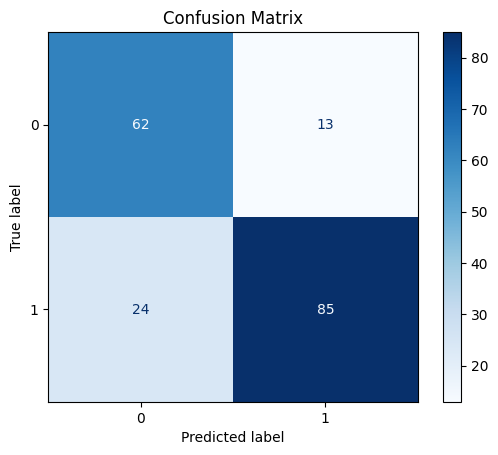

In [175]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [176]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [177]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>